# TP1

In [1]:
from src.utils import retrieve_patterns
from src.hopfield import Hopfield
from src.pattern import Pattern
from collections import defaultdict


patterns = defaultdict(list)
for pattern in retrieve_patterns("images"):
    patterns[len(pattern)].append(pattern)

models = {}
for size, ps in patterns.items():
    m = Hopfield(size)
    m.train(ps)
    models[size] = m

## Imágenes

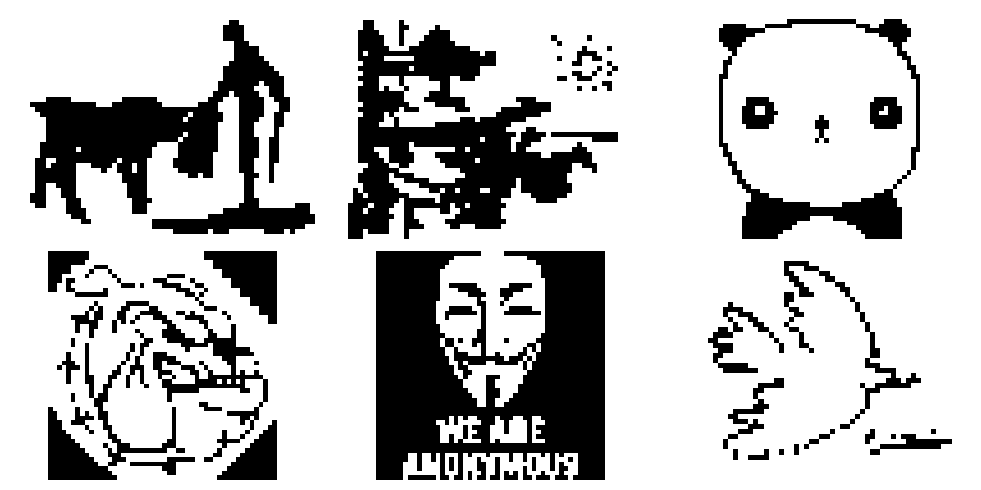

In [2]:
import matplotlib.pyplot as plt
from src.utils import retrieve_images


images = list(retrieve_images("images"))
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 5))

for ax, image in zip(axes.flat, images):
    ax.imshow(image, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.show()

## a) Verifique si la red aprendió las imágenes enseñadas

In [3]:
for size, m in models.items():
    ps = patterns[size]

    for p in ps:
        if not m.is_stable(p):
            raise Exception(f"network failed to learn {p.name}")

## b) Evalúe la evolución de la red al presentarle versiones alteradas de las imágenes aprendidas: agregado de ruido, elementos borrados o agregados.

In [4]:
import matplotlib.pyplot as plt
from typing import Callable, Iterable
from math import sqrt


def recall_with(m: Hopfield, p: Pattern, f: Callable) -> tuple[int, int]:
    noisy = f(p)
    closest, steps = m.recall(noisy)
    dist = sum(int(closest[i] != p[i]) for i in range(len(p)))
    return steps, dist


def steps_dists_to_converge(size: int, ks: Iterable[int], f: Callable) -> tuple[list[float], list[float]]:
    ps = patterns[size]
    m = models[size]

    steps, dists = [], []

    for k in ks:
        k = min(k, size)
        steps_sum, dists_sum = 0, 0

        for p in ps:
            steps_taken, dist = recall_with(m, p, lambda x: f(x, k))
            steps_sum += steps_taken
            dists_sum += dist

        steps.append(steps_sum / len(ps))
        dists.append(dists_sum / len(ps))

    return steps, dists


def plot(size: int, f: Callable, xlabel: str):
    ks = list(range(0, size + 1, size // 10))
    steps, dists = steps_dists_to_converge(size, ks, flip_bytes)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.plot(ks, dists)
    ax1.set_title(f"Mean distances to the original pattern")
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("Hamming distance (neurons)")

    ax2.plot(ks, steps)
    ax2.set_title(f"Mean steps to converge")
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("Steps taken to converge")

    fig.suptitle(f"Hopfield Network with {size} neurons", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### Neuronas invertidas

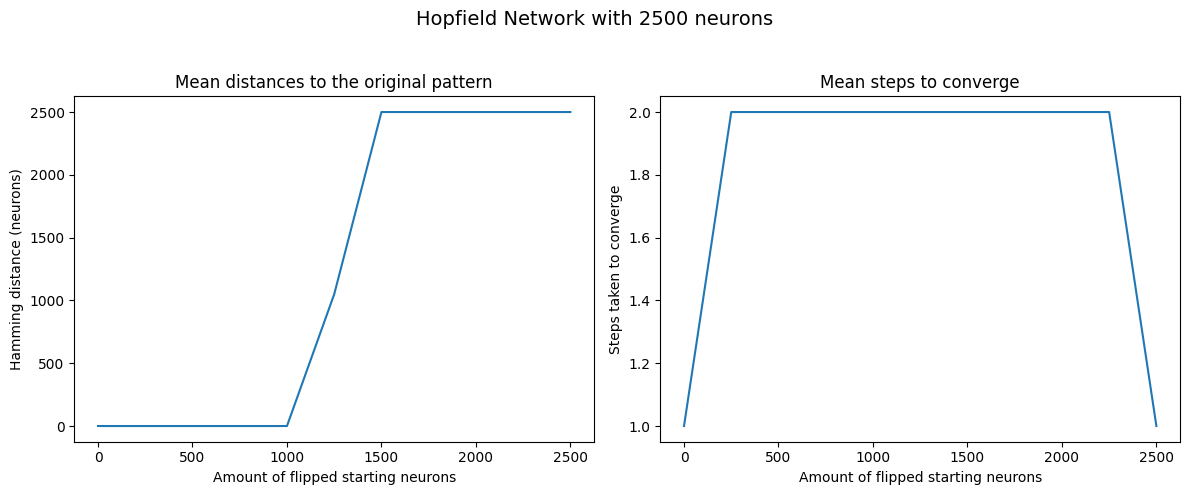

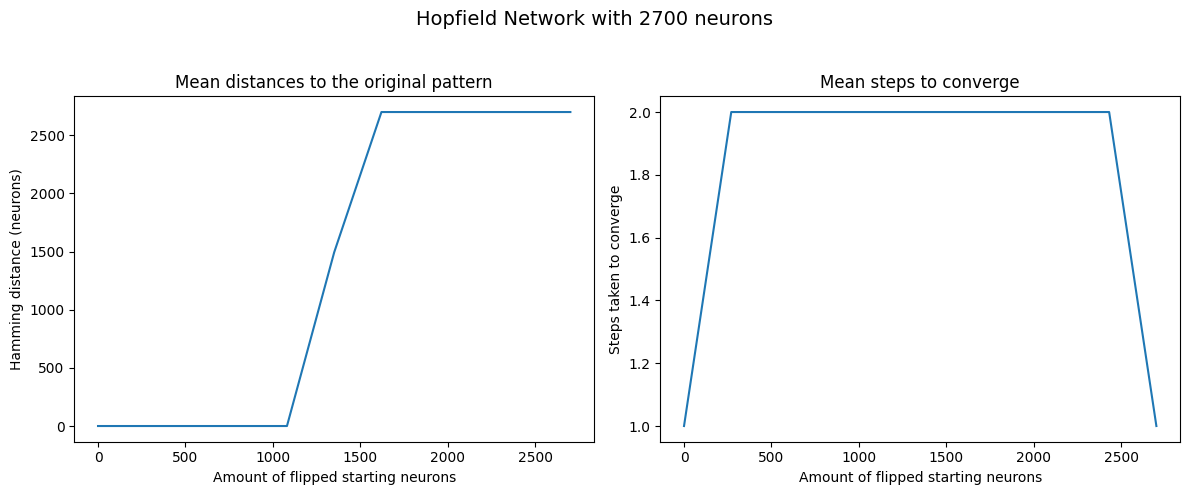

In [5]:
from src.utils import flip_bytes

for size in sorted(patterns):
    plot(size, flip_bytes, "Amount of flipped starting neurons")

#### Neuronas seteadas a 1

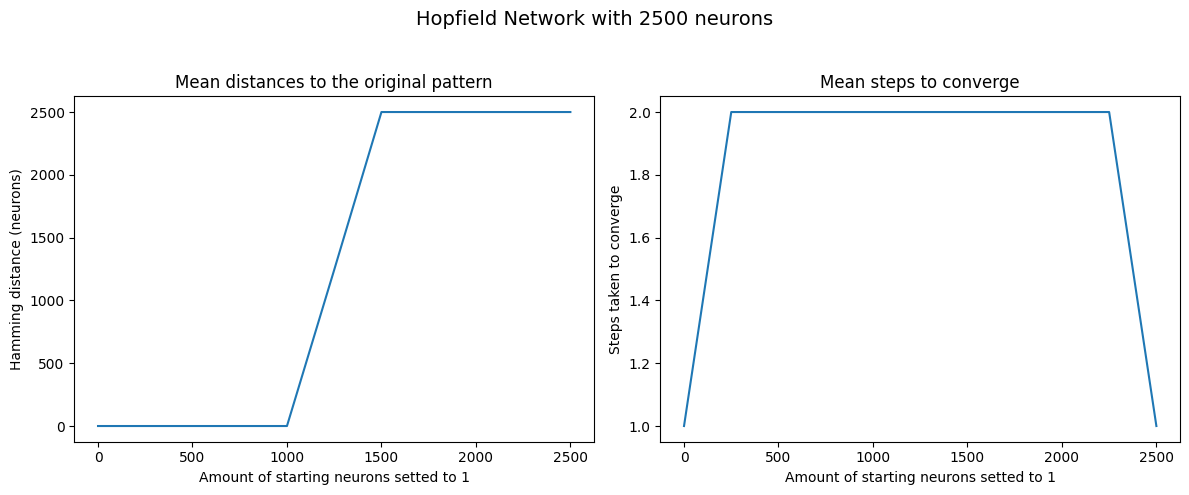

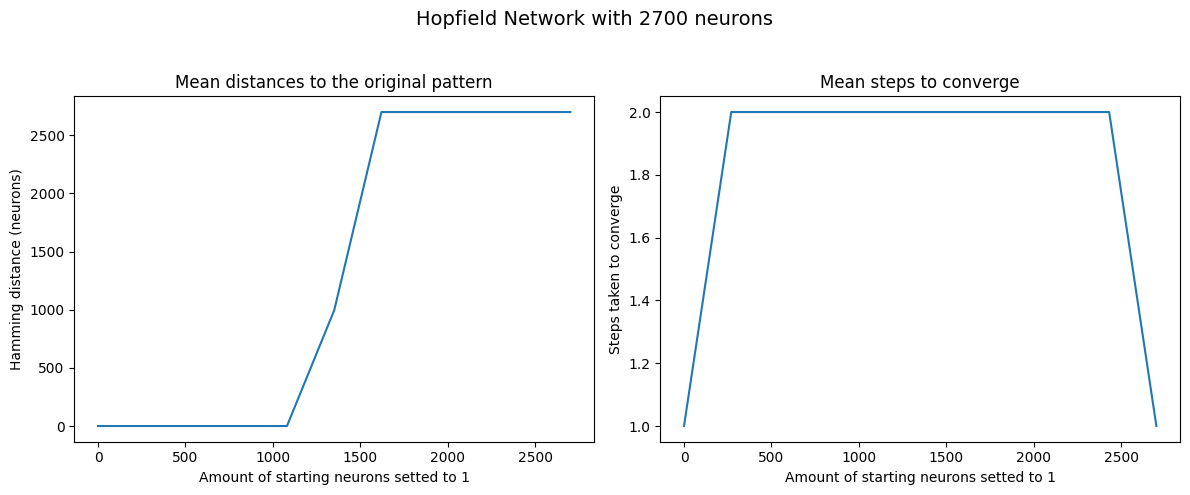

In [6]:
from src.utils import paint_bytes

for size in sorted(patterns):
    plot(size, lambda p, k: paint_bytes(p, k, 1), "Amount of starting neurons setted to 1")

#### Neuronas seteadas a -1

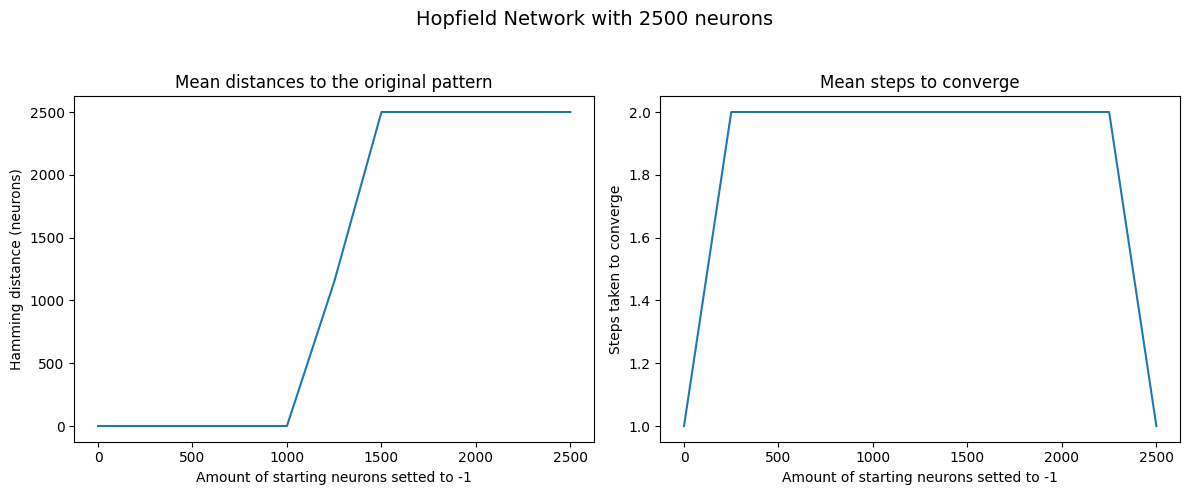

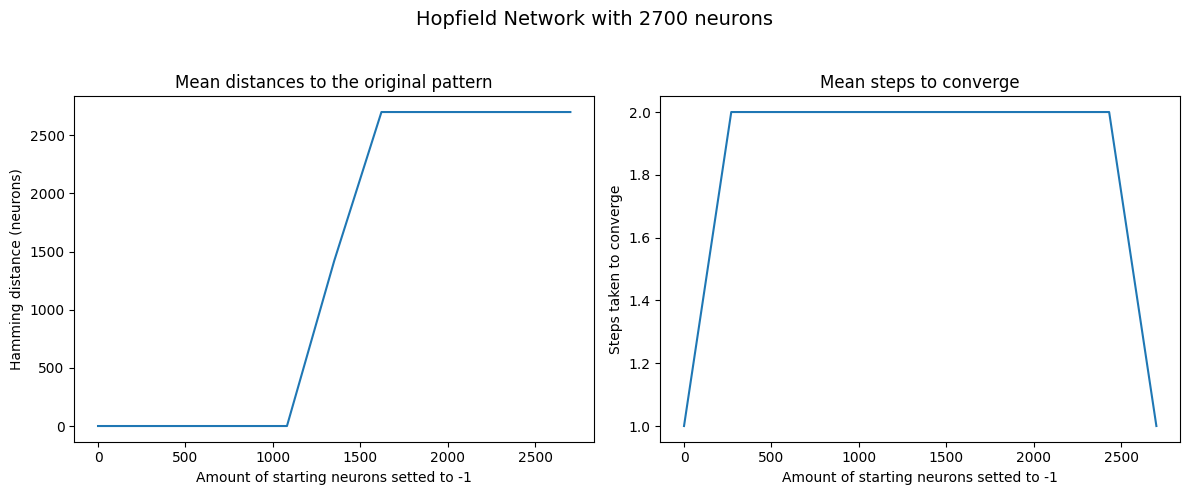

In [7]:
from src.utils import paint_bytes

for size in sorted(patterns):
    plot(size, lambda p, k: paint_bytes(p, k, -1), "Amount of starting neurons setted to -1")

## c) Evalúe la existencia de estados espurios en la red: patrones inversos y combinaciones de un número impar de patrones. (Ver Spurious States, en la sección 2.2, Hertz, Krogh & Palmer, pág. 24).

#### Patrones inversos

In [8]:
for size, m in models.items():
    ps = patterns[size]

    for p in ps:
        if not m.is_stable(-p):
            raise Exception(f"{p.name} is not a spurious state")

#### Combinaciones de un número impar de patrones

In [9]:
from src.utils import all_linear_combs

for size, m in models.items():
    combs = all_linear_combs(patterns[size])
    
    for p in combs:
        if not m.is_stable(p):
            raise Exception(f"{p.name} is not a spurious state")

## d) Realice un entrenamiento con las 6 imágenes disponibles. ¿Es capaz la red de aprender todas las imágenes? Explique

In [7]:
from src.utils import retrieve_patterns


mheight = max(im.shape[0] for im in images)
mwidth = max(im.shape[1] for im in images)

m = Hopfield(mwidth * mheight)
padded = list(retrieve_patterns("images", (mwidth, mheight)))
m.train(padded)

for p in padded:
    if not m.is_stable(p):
        raise Exception(f"network failed to learn {p.name}")

Exception: network failed to learn quijote.bmp